In [1]:
%matplotlib inline

detectron2: 0.6
zsh:1: command not found: wget


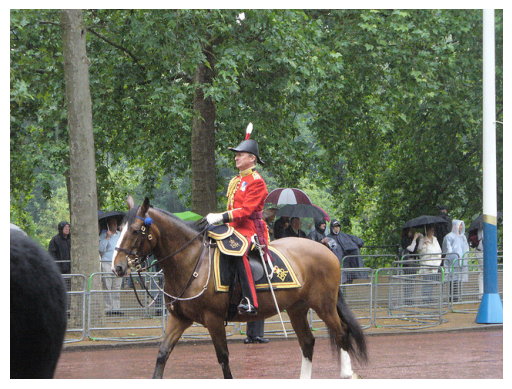

[07/16 15:03:56 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from https://dl.fbaipublicfiles.com/detectron2/COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x/137849600/model_final_f10217.pkl ...


/opt/anaconda3/envs/bagigio/lib/python3.9/site-packages/torch/functional.py:512: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /Users/runner/work/_temp/anaconda/conda-bld/pytorch_1716905753886/work/aten/src/ATen/native/TensorShape.cpp:3588.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


tensor([17,  0,  0,  0,  0,  0,  0,  0, 25,  0, 25, 25,  0,  0, 24])
Boxes(tensor([[126.6035, 244.8977, 459.8291, 480.0000],
        [251.1083, 157.8127, 338.9731, 413.6379],
        [114.8496, 268.6864, 148.2352, 398.8111],
        [  0.8217, 281.0327,  78.6072, 478.4210],
        [ 49.3954, 274.1229,  80.1545, 342.9808],
        [561.2248, 271.5816, 596.2755, 385.2552],
        [385.9072, 270.3125, 413.7130, 304.0397],
        [515.9295, 278.3743, 562.2792, 389.3803],
        [335.2409, 251.9167, 414.7491, 275.9375],
        [350.9300, 269.2060, 386.0984, 297.9081],
        [331.6292, 230.9996, 393.2759, 257.2009],
        [510.7349, 263.2656, 570.9865, 295.9194],
        [409.0841, 271.8646, 460.5582, 356.8722],
        [506.8767, 283.3257, 529.9403, 324.0392],
        [594.5663, 283.4820, 609.0577, 311.4124]]))


In [2]:
import cv2
import torch, detectron2
import matplotlib.pyplot as plt


print("detectron2:", detectron2.__version__)
# Some basic setup:
# Setup detectron2 logger
import detectron2
from detectron2.utils.logger import setup_logger
setup_logger()

# import some common libraries
import numpy as np
import os, json, cv2, random

from PIL import Image, ImageDraw

# import some common detectron2 utilities
from detectron2 import model_zoo
from detectron2.engine import DefaultPredictor
from detectron2.config import get_cfg
from detectron2.utils.visualizer import Visualizer
from detectron2.data import MetadataCatalog, DatasetCatalog
!wget http://images.cocodataset.org/val2017/000000439715.jpg -q -O input.jpg
im = cv2.imread("./input.jpg")
# Convert the image from BGR to RGB
im_rgb = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)


# Display the image using matplotlib
plt.imshow(im_rgb)
plt.axis('off')  # Hide the axis
plt.show()
cfg = get_cfg()
cfg
cfg.MODEL.DEVICE = 'cpu'
cfg.MODEL
cfg.MODEL.RPN.BATCH_SIZE_PER_IMAGE = 2
cfg.MODEL.ROI_HEADS.BATCH_SIZE_PER_IMAGE = 4
cfg.MODEL.DEVICE

# add project-specific config (e.g., TensorMask) here if you're not running a model in detectron2's core library
cfg.merge_from_file(model_zoo.get_config_file("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml"))
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5  # set threshold for this model
# Find a model from detectron2's model zoo. You can use the https://dl.fbaipublicfiles... url as well
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml")
predictor = DefaultPredictor(cfg)
outputs = predictor(im)

print(outputs["instances"].pred_classes)
print(outputs["instances"].pred_boxes)


In [3]:
import torch, detectron2
!nvcc --version
TORCH_VERSION = ".".join(torch.__version__.split(".")[:2])
CUDA_VERSION = torch.__version__.split("+")[-1]
print("torch: ", TORCH_VERSION, "; cuda: ", CUDA_VERSION)
print("detectron2:", detectron2.__version__)

zsh:1: command not found: nvcc
torch:  2.3 ; cuda:  2.3.1
detectron2: 0.6


Code for load and 'register' our dataset in detectron format

In [4]:
from detectron2.data.datasets import register_coco_instances, load_coco_json

register_coco_instances("my_dataset", {}, "refcocog/annotations/instances.json", "refcocog/images")

In [7]:
dict_out = DatasetCatalog.get("my_dataset")
metadata = MetadataCatalog.get("my_dataset")

[07/16 15:04:38 d2.data.datasets.coco]: Loading refcocog/annotations/instances.json takes 2.21 seconds.
WARNING [07/16 15:04:38 d2.data.datasets.coco]: 
Category ids in annotations are not in [1, #categories]! We'll apply a mapping for you.

[07/16 15:04:38 d2.data.datasets.coco]: Loaded 25799 images in COCO format from refcocog/annotations/instances.json


In [9]:
cfg.DATASETS.TRAIN = ("my_dataset",)

In [11]:
from detectron2.data import build_detection_train_loader
from detectron2.data import DatasetMapper
import detectron2.data.transforms as T

# dataloader = build_detection_train_loader(dict_out,
#    mapper=DatasetMapper(cfg, is_train=True, augmentations=[
#       T.Resize((800, 800))
#    ]), total_batch_size=1)
#dataloader = build_detection_train_loader(cfg, mapper=DatasetMapper(cfg, is_train=True, augmentations=[T.Resize((800, 800))]))
dataloader = build_detection_train_loader(cfg)
dataloader

[07/16 15:13:30 d2.data.datasets.coco]: Loading refcocog/annotations/instances.json takes 2.44 seconds.
WARNING [07/16 15:13:30 d2.data.datasets.coco]: 
Category ids in annotations are not in [1, #categories]! We'll apply a mapping for you.

[07/16 15:13:31 d2.data.datasets.coco]: Loaded 25799 images in COCO format from refcocog/annotations/instances.json
[07/16 15:13:31 d2.data.build]: Removed 0 images with no usable annotations. 25799 images left.
[07/16 15:13:31 d2.data.build]: Distribution of instances among all 80 categories:
|   category    | #instances   |   category   | #instances   |   category    | #instances   |
|:-------------:|:-------------|:------------:|:-------------|:-------------:|:-------------|
|    person     | 55044        |   bicycle    | 1612         |      car      | 8947         |
|  motorcycle   | 1848         |   airplane   | 1243         |      bus      | 1719         |
|     train     | 981          |    truck     | 2717         |     boat      | 1548    

In [12]:
from detectron2.modeling import build_model

model = build_model(cfg)

In [20]:
# from detectron2.utils.events import EventStorage

# loss = []

# with EventStorage() as storage:
#   for data, iteration in zip(dataloader, range(0, 50)):
#     print(iteration)
#     losses = model(data)
#     loss.append(losses)



0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49


In [22]:
# print(loss[-1])

[{'instances': Instances(num_instances=2, image_height=612, image_width=612, fields=[pred_boxes: Boxes(tensor([[  2.9688,   0.0000,   2.9831, 612.0000],
        [  0.0000,   0.0000, 612.0000, 612.0000]], grad_fn=<IndexBackward0>)), scores: tensor([1., 1.], grad_fn=<IndexBackward0>), pred_classes: tensor([79, 51]), pred_masks: tensor([[[False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False],
         ...,
         [False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False]],

        [[False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False],
         ...,
         [False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, F

In [13]:
gt = 0
pred = 0
path = 0

model.eval()
with torch.no_grad():
    for d in dataloader:

        path = d[0]['file_name']
        print("\nPath Image\n")
        print(path)
        gt = d[0]["instances"].gt_boxes
        print("\nGround Truth\n")
        print(gt)
        outputs = model(d)
        pred = outputs[0]["instances"].pred_boxes
        #print(outputs[0])
        #print(outputs[0]["instances"].pred_classes)
        print("\npredicted\n")
        print(pred)

        break



Path Image

refcocog/images/COCO_train2014_000000312841.jpg

Ground Truth

Boxes(tensor([[ 60.2500, 429.6530, 200.2415, 664.4034],
        [494.0429, 372.8813, 680.9042, 638.1078],
        [254.6271,  37.7691, 561.7300, 603.6425],
        [242.5614, 150.1999, 373.1497, 583.7522]]))

predicted

Boxes(tensor([[247.8061,   0.0000, 640.0000, 598.0000],
        [109.7963,   0.0000, 109.8282, 598.0000],
        [529.8765,   0.0000, 529.8766, 598.0000],
        [514.5472,   0.0000, 514.8367, 598.0000],
        [311.7131,   0.0000, 311.7274, 598.0000],
        [  0.0000,   0.0000, 640.0000, 598.0000],
        [  0.0000,  72.7556, 640.0000, 598.0000],
        [423.9424,   0.0000, 437.6499, 598.0000],
        [166.5250,   0.0000, 503.9917, 598.0000],
        [409.2331,   0.0000, 424.9971, 598.0000],
        [418.3651,   0.0000, 446.7637, 598.0000]]))


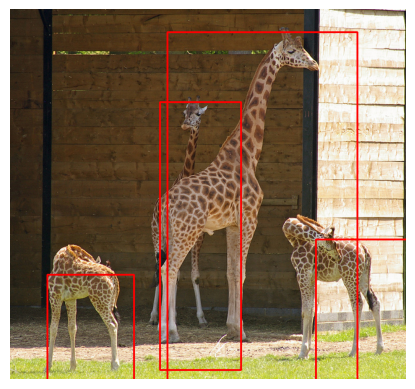

In [15]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

# Define colors
max_bbox_color = (0, 255, 0)  # Green for the highest score bbox
other_bbox_color = (0, 0, 255)  # Red for other bboxes


# Read the image
image = cv2.imread(path)

# Crea una figura e una serie di subplot
fig, ax = plt.subplots(1)
ax.imshow(image)
gt2 = gt.tensor

# Aggiungi le bounding boxes all'immagine
for box in gt2:
    
    x_min, y_min, x_max, y_max = box
    color = other_bbox_color
    cv2.rectangle(image, (int(x_min), int(y_min)) ,(int(x_max), int(y_max)), color, 2)

    
    # width = x_max - x_min
    # height = y_max - y_min
    # rect = patches.Rectangle((x_min, y_min), width, height, linewidth=2, edgecolor='r', facecolor='none')
    # ax.add_patch(rect)

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Display the image
plt.imshow(image_rgb)
plt.axis('off')
plt.show()

tensor(419.3000)

refcocog/images/COCO_train2014_000000000009.jpg


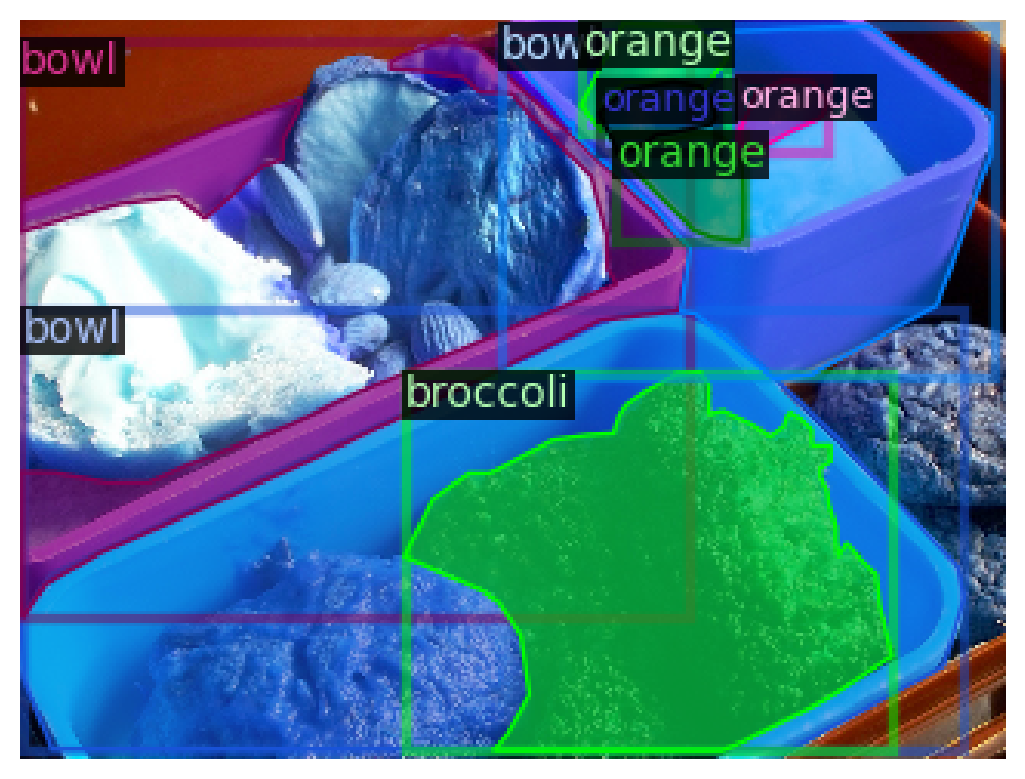

In [10]:
for d in dict_out:
    img = cv2.imread(d["file_name"])
    print(d['file_name'])
    if img is not None:
        visualizer = Visualizer(img[:, :, ::-1], metadata=metadata, scale=0.5)
        out = visualizer.draw_dataset_dict(d)
        #cv2.imshow("output", out.get_image()[:, :, ::-1])
        plt.imshow(out.get_image()[:, :, ::-1])
        plt.show()
        break

In [11]:
from detectron2.engine import DefaultTrainer

#cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml"))
cfg.DATASETS.TRAIN = ("my_dataset",)
cfg.DATASETS.TEST = ()
cfg.DATALOADER.NUM_WORKERS = 2
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml")  # Let training initialize from model zoo
cfg.SOLVER.IMS_PER_BATCH = 2  # This is the real "batch size" commonly known to deep learning people
cfg.SOLVER.BASE_LR = 0.00025  # pick a good LR
cfg.SOLVER.MAX_ITER = 300    # 300 iterations seems good enough for this toy dataset; you will need to train longer for a practical dataset
cfg.SOLVER.STEPS = []        # do not decay learning rate
cfg.MODEL.ROI_HEADS.BATCH_SIZE_PER_IMAGE = 128   # The "RoIHead batch size". 128 is faster, and good enough for this toy dataset (default: 512)
cfg.MODEL.ROI_HEADS.NUM_CLASSES = 80  # only has one class (ballon). (see https://detectron2.readthedocs.io/tutorials/datasets.html#update-the-config-for-new-datasets)
# NOTE: this config means the number of classes, but a few popular unofficial tutorials incorrect uses num_classes+1 here.

os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)
trainer = DefaultTrainer(cfg)
trainer.resume_or_load(resume=False)
#trainer.train()
try:
    trainer.train()
except FileNotFoundError as e:
    print(f"File not found: {e}")

[07/16 11:51:02 d2.engine.defaults]: Model:
GeneralizedRCNN(
  (backbone): FPN(
    (fpn_lateral2): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral3): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral4): Conv2d(1024, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral5): Conv2d(2048, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output5): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (top_block): LastLevelMaxPool()
    (bottom_up): ResNet(
      (stem): BasicStem(
        (conv1): Conv2d(
          3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
          (norm): FrozenBatchNorm2d(num_features=64, eps=1e-05)
        )
      )
      (res

KeyboardInterrupt: 